#XGBOOST

In [24]:
from pyspark.ml.feature import VectorAssembler
from xgboost.spark import SparkXGBClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

In [25]:
# Vector Assembler

df = df.withColumnRenamed("Loan_Status", "label")


assembler = VectorAssembler( inputCols = [
    "Age",
    "Income",
    "LoanAmount",
    "Credit_Score",
    "Employment_Years",
    "Credit_History",
    "Has_Defaulted",
    "Dependents",
    "Gender",
    "Education_Level",
    "Married",
    "Job_Type",
    "Property_Area"
],
outputCol = "features",
handleInvalid = "keep"
)

df_final = assembler.transform(df)

In [26]:
# Train and Test split

train_df, test_df = df_final.randomSplit([0.8, 0.2], seed = 42)
print(f"Train: {train_df.count()} row" )
print(f"Test: {test_df.count()} row")

Train: 815929 row
Test: 204071 row


#XGBoost Model (Spark)

In [27]:

xgb = SparkXGBClassifier(
    features_col="features",
    label_col="label",
    prediction_col="prediction",
    probability_col="probability",
    max_depth=6,
    eta=0.1,
    num_round=100
)

In [28]:
model = xgb.fit(train_df)

INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'device': 'cpu', 'max_depth': 6, 'eta': 0.1, 'num_round': 100, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


In [29]:
#Prediction
predictions = model.transform(test_df)
predictions.select("label", "prediction", "probability").show(10)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.95937120914459...|
|    1|       1.0|[0.40401041507720...|
|    0|       0.0|[0.97973084449768...|
|    1|       1.0|[0.11599409580230...|
|    0|       0.0|[0.95239037275314...|
|    0|       0.0|[0.83780628442764...|
|    1|       0.0|[0.85575747489929...|
|    1|       1.0|[0.03742492198944...|
|    1|       1.0|[0.24065315723419...|
|    1|       1.0|[0.02303493022918...|
+-----+----------+--------------------+
only showing top 10 rows


#Evaluation

In [30]:
#Accuracy
acc_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

In [31]:
# F1 Score
f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

In [32]:
#AUC
auc_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

In [33]:
#Precision
precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(predictions)

In [34]:
#Recall
recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(predictions)

In [35]:
print("accuracy : ", acc_eval.evaluate(predictions))
print("f1 :", f1_eval.evaluate(predictions))
print("areaUnderROC :", auc_eval.evaluate(predictions))
print("Precision:", precision)
print("Recall:", recall)

accuracy :  0.821635607215136
f1 : 0.8202294998487633
areaUnderROC : 0.8993512867260233
Precision: 0.8206138547490114
Recall: 0.8216356072151358


Importance

In [41]:
import pandas as pd

importance = model.get_booster().get_score(importance_type='gain')

feature_names = assembler.getInputCols()

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": [importance.get(f"f{i}", 0.0) for i in range(len(feature_names))]
})

fi["importance_pct"] = fi["importance"] / fi["importance"].sum() * 100

fi = fi.sort_values(by="importance_pct", ascending=False)

print(fi)

             feature   importance  importance_pct
5     Credit_History  2326.521729       38.200233
6      Has_Defaulted  1063.530151       17.462592
11          Job_Type   938.156189       15.404019
3       Credit_Score   588.085999        9.656055
4   Employment_Years   321.344330        5.276301
1             Income   160.325180        2.632453
0                Age   134.327850        2.205591
9    Education_Level   113.886787        1.869960
2         LoanAmount   108.625443        1.783571
7         Dependents    96.292648        1.581073
10           Married    92.024017        1.510985
12     Property_Area    83.785645        1.375715
8             Gender    63.427948        1.041453


#Visualization XGBOOST

Confusion Matrix

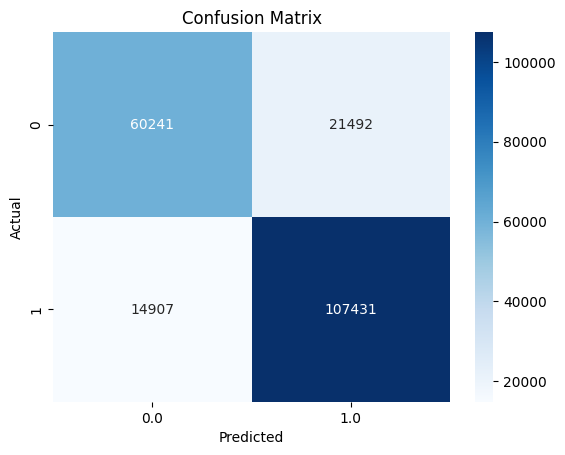

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pred_pd = predictions.select("label", "prediction").toPandas()

cm = pd.crosstab(pred_pd["label"], pred_pd["prediction"])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC Curve

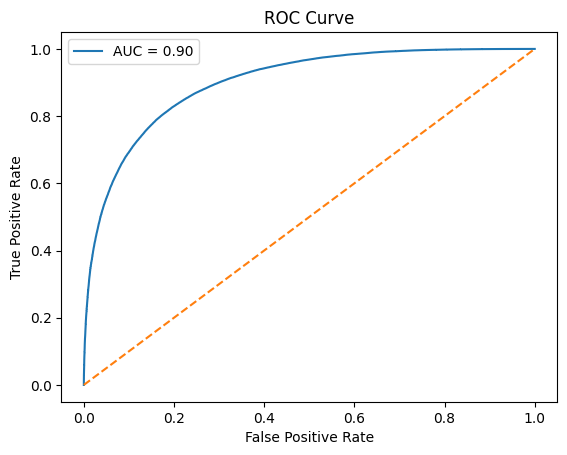

In [43]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

pred_pd = predictions.select("label", "probability").toPandas()

y_true = predictions.select("label").toPandas()["label"]
y_score = pred_pd["probability"].apply(lambda x: float(x[1]))

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], '--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Feature Importance

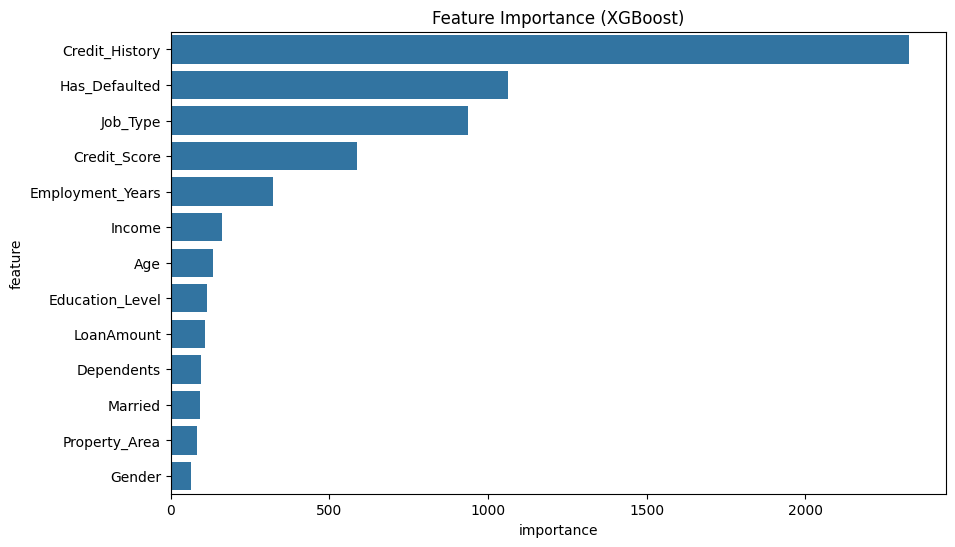

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importance = model.get_booster().get_score(importance_type='gain')

feature_names = assembler.getInputCols()

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": [importance.get(f"f{i}", 0) for i in range(len(feature_names))]
})

fi = fi.sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=fi)
plt.title("Feature Importance (XGBoost)")
plt.show()

#Save Model

In [47]:
model.write().overwrite().save("xgboost_model")
#pipelineModel.write().save("pipeline_model")